IMPORT LIBRARIES

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import numpy as np

In [6]:
path = "online_gaming_behavior_dataset.csv"
df = pd.read_csv(path)
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [30]:
df.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

C:\Users\rigel\AppData\Local\Temp\ipykernel_32748\3264164949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='EngagementLevel', data=df, palette='viridis')


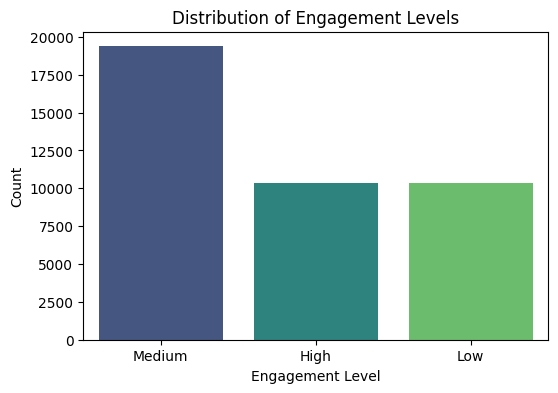

In [ ]:
df.info()
df['EngagementLevel'].value_counts()

# Visualizzo la distribuzione di Engagement Levels
plt.figure(figsize=(6,4))
sns.countplot(x='EngagementLevel', data=df, palette='viridis')
plt.title('Distribution of Engagement Levels')
plt.xlabel('Engagement Level')
plt.ylabel('Count')
plt.show()


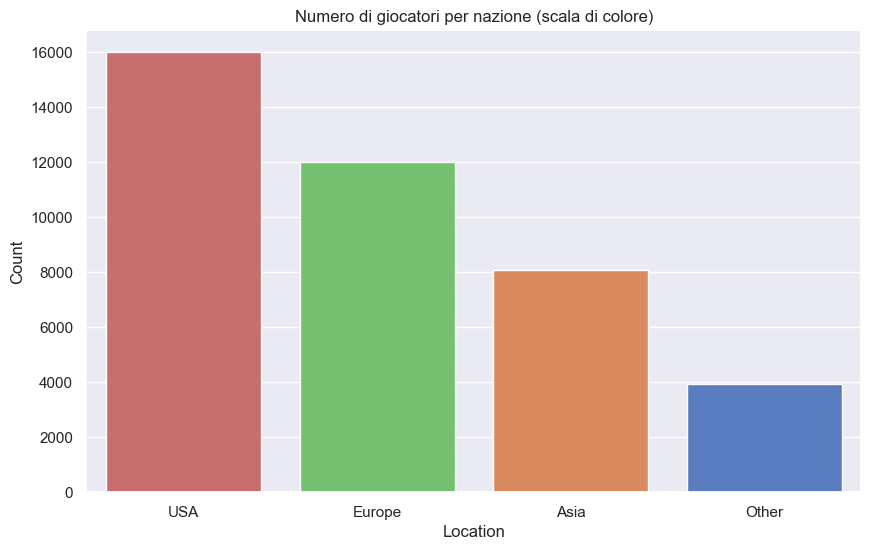

In [126]:
location = df["Location"].value_counts().reset_index()
location.columns = ['Location', 'Count']

plt.figure(figsize=(10,6))
sns.barplot(data=location, x='Location', y='Count', hue='Count', palette="muted", dodge=False, legend=False)

plt.title("Numero di giocatori per nazione (scala di colore)")
plt.show()


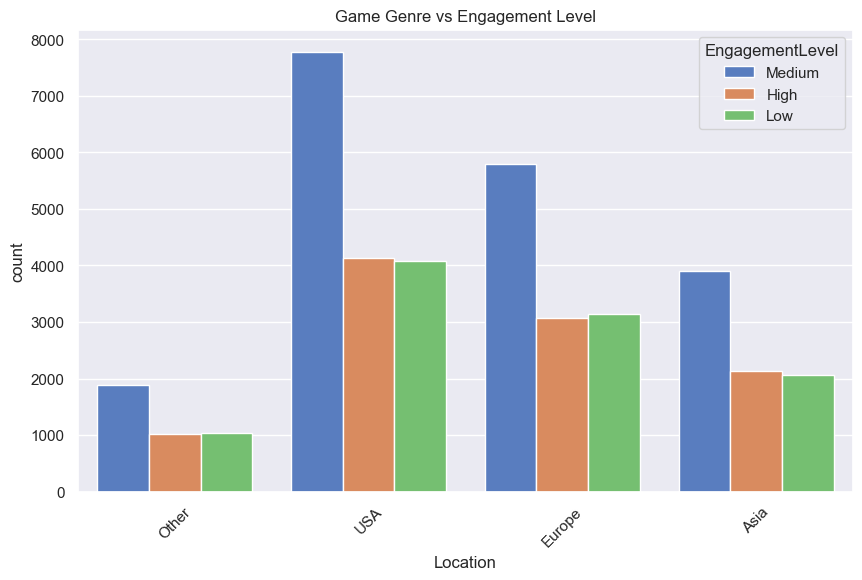

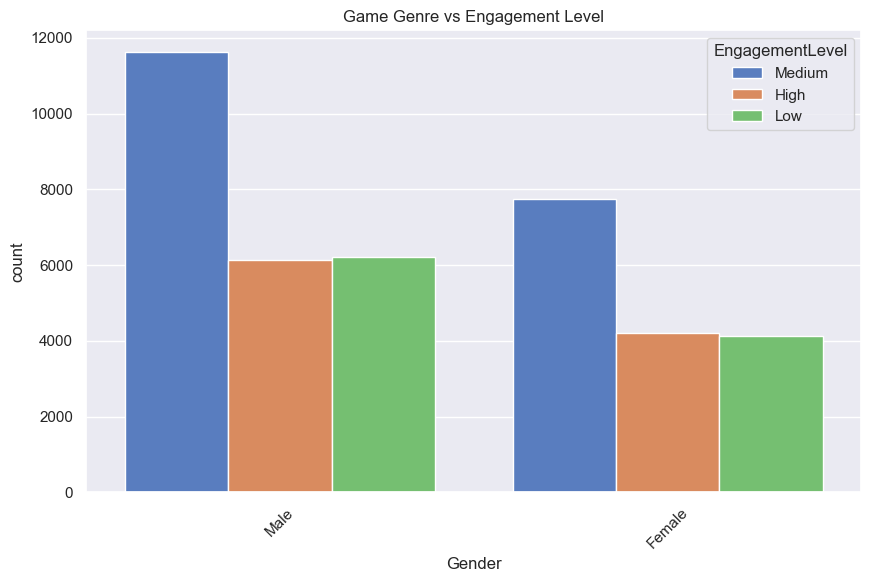

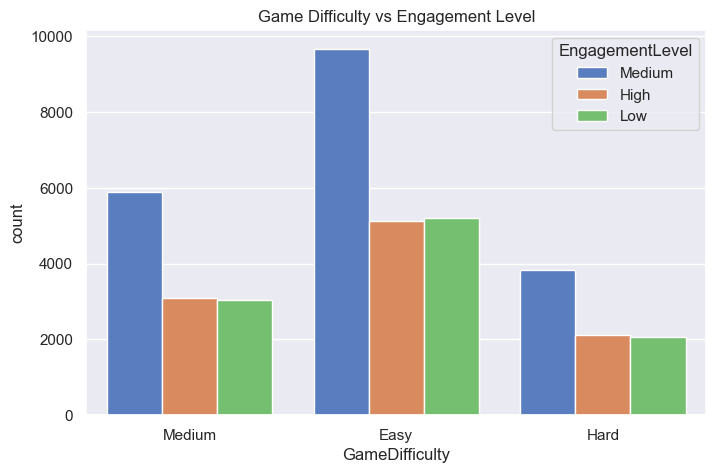

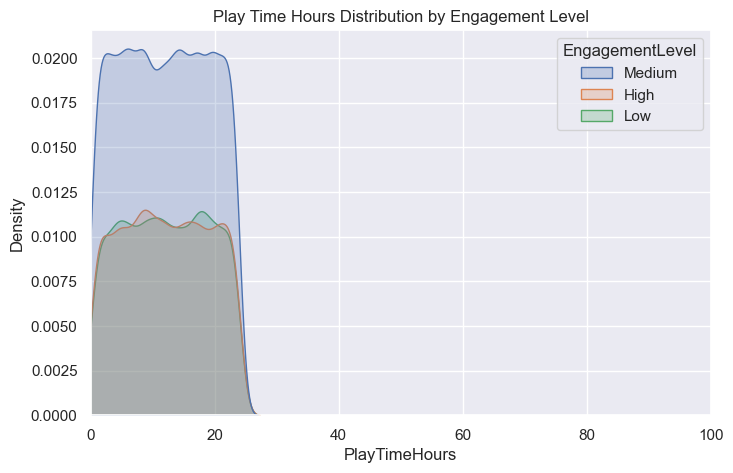

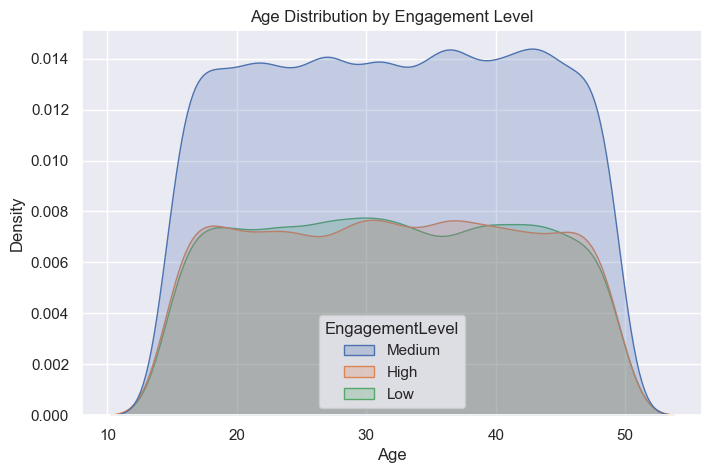

In [ ]:
# Separate out Medium engagement players
medium_players = df[df['EngagementLevel'] == 'Medium']

# Compare against Low and High engagement
low_players = df[df['EngagementLevel'] == 'Low']
high_players = df[df['EngagementLevel'] == 'High']

# Game Genre vs Engagement Level
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='GameGenre', hue='EngagementLevel', palette='muted')
plt.title('Game Genre vs Engagement Level')
plt.xticks(rotation=45)
plt.show()

# Gender vs Engagement Level
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Gender', hue='EngagementLevel', palette='muted')
plt.title('Gender vs Engagement Level')
plt.xticks(rotation=45)
plt.show()

# Game Difficulty vs Engagement Level
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='GameDifficulty', hue='EngagementLevel', palette='muted')
plt.title('Game Difficulty vs Engagement Level')
plt.show()

# Play Time Hours Distribution by Engagement Level
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='PlayTimeHours', hue='EngagementLevel', fill=True)
plt.title('Play Time Hours Distribution by Engagement Level')
plt.xlim(0, 100)  # limit for better focus
plt.show()

# Age Distribution by Engagement Level
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='Age', hue='EngagementLevel', fill=True)
plt.title('Age Distribution by Engagement Level')
plt.show()

In [ ]:
#copio dataframe e seleziono le colonne da convertire
df_new = df.copy()
df_drop_playerID = df.drop(columns='PlayerID', inplace=False)
obj_cols = df_new.select_dtypes(include=['object']).columns
# converto le colonne da string a  int
encoder = LabelEncoder()
for col in obj_cols:
    df_drop_playerID[col] = encoder.fit_transform(df_drop_playerID[col])

df_drop_playerID.head()

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,43,1,2,4,16.271119,0,2,6,108,79,25,2
1,29,0,3,4,5.525961,0,2,5,144,11,10,2
2,22,0,3,3,8.223755,0,0,16,142,35,41,0
3,35,1,3,0,5.265351,1,0,9,85,57,47,2
4,33,1,1,0,15.531945,0,2,2,131,95,37,2


<Axes: >

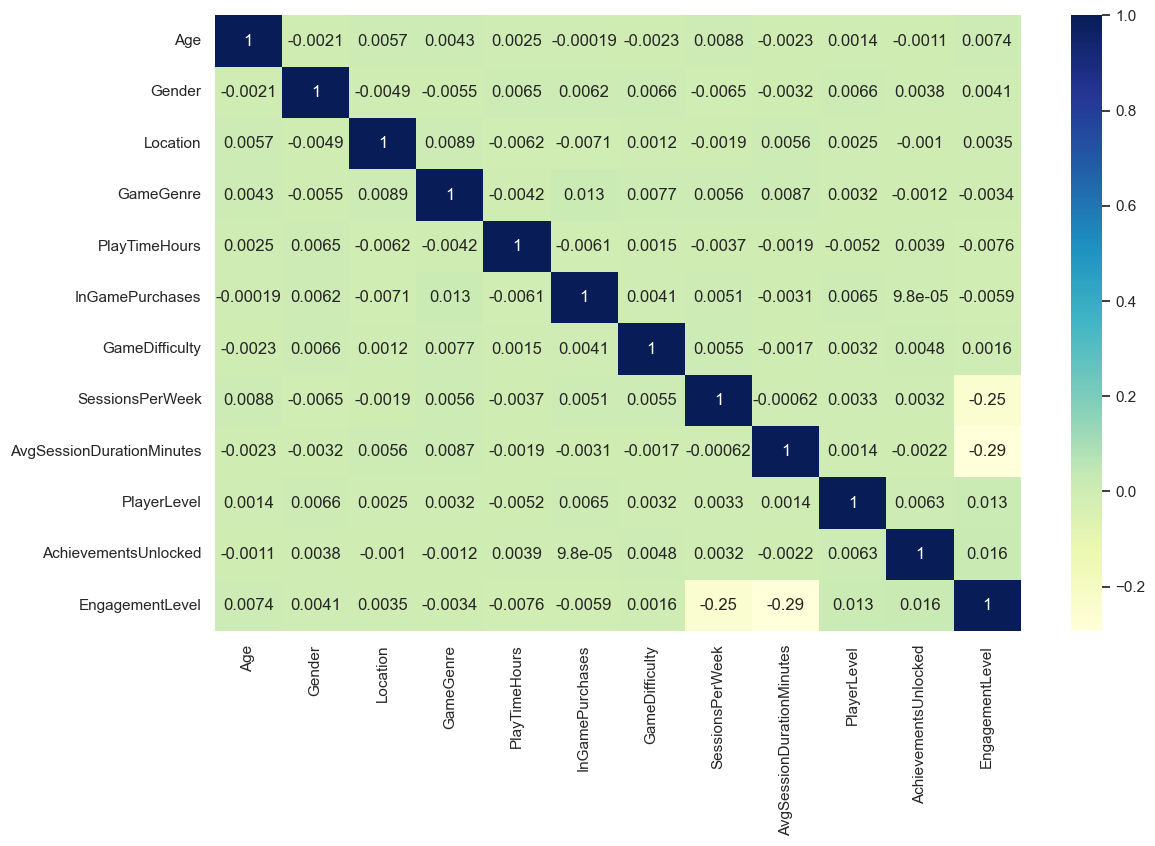

In [80]:
#visualizzo in un grafico heatmap di correlazione
sns.set_theme(rc={'figure.figsize': (13, 8)})
sns.heatmap(df_drop_playerID.corr(), annot=True, cmap='YlGnBu')